
Training with 20% of training data


C:\Users\shubh\anaconda3\lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Test Accuracy: 61.42%

Training with 40% of training data
Test Accuracy: 67.83%

Training with 60% of training data
Test Accuracy: 70.33%

Training with 80% of training data
Test Accuracy: 70.65%

Training with 100% of training data
Test Accuracy: 71.10%


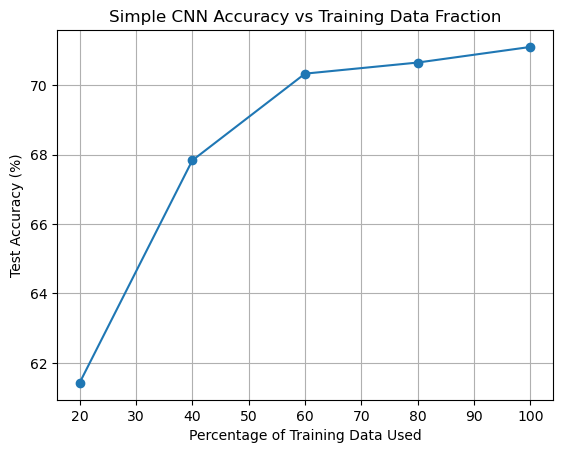

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt

# Hyperparameters
BATCH_SIZE_TRAIN = 128
BATCH_SIZE_TEST = 256
NUM_WORKERS = 4
NUM_EPOCHS = 10  # adjust as needed
LEARNING_RATE = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1) Preprocessing and Data Loading
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616)),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616)),
])

full_train_dataset = datasets.CIFAR10(root='cifar10', train=True, download=True, transform=transform_train)
full_test_dataset  = datasets.CIFAR10(root='cifar10', train=False, download=True, transform=transform_test)

def get_loaders(fraction):
    subset_size = int(len(full_train_dataset) * fraction)
    indices = torch.randperm(len(full_train_dataset))[:subset_size]
    train_subset = Subset(full_train_dataset, indices)
    train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE_TRAIN,
                              shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
    test_loader = DataLoader(full_test_dataset, batch_size=BATCH_SIZE_TEST,
                             shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    return train_loader, test_loader

# 2) Define a simple CNN
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# 3) Experiment over fractions
fractions = [0.2, 0.4, 0.6, 0.8, 1.0]
accuracies = []

for frac in fractions:
    print(f"\nTraining with {int(frac*100)}% of training data")
    train_loader, test_loader = get_loaders(frac)

    # instantiate model for each fraction\
    model = SimpleCNN().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss()

    # train   
    for epoch in range(1, NUM_EPOCHS+1):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

    # evaluate on full test set\ n    
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            correct += (logits.argmax(1) == yb).sum().item()
            total += yb.size(0)
    acc = 100 * correct / total
    print(f"Test Accuracy: {acc:.2f}%")
    accuracies.append(acc)

# 4) Plot results\ nplt.figure(figsize=(8,5))
plt.plot([int(f*100) for f in fractions], accuracies, marker='o')
plt.xlabel("Percentage of Training Data Used")
plt.ylabel("Test Accuracy (%)")
plt.title("Simple CNN Accuracy vs Training Data Fraction")
plt.grid(True)
plt.show()


Successfully received priors from the local LLM.

Training with 20% of real data
Starting training...
Epoch: 1, Loss: 2.0102, Accuracy: 24.54%
Epoch: 2, Loss: 1.8045, Accuracy: 32.93%
Epoch: 3, Loss: 1.7517, Accuracy: 34.76%
Epoch: 4, Loss: 1.6627, Accuracy: 38.29%
Epoch: 5, Loss: 1.6165, Accuracy: 40.54%
Epoch: 6, Loss: 1.5574, Accuracy: 42.10%
Epoch: 7, Loss: 1.4966, Accuracy: 45.24%
Epoch: 8, Loss: 1.4732, Accuracy: 45.76%
Epoch: 9, Loss: 1.4173, Accuracy: 47.97%
Epoch: 10, Loss: 1.3910, Accuracy: 49.12%
Epoch: 11, Loss: 1.3667, Accuracy: 51.05%
Epoch: 12, Loss: 1.3434, Accuracy: 51.11%
Epoch: 13, Loss: 1.2939, Accuracy: 52.82%
Epoch: 14, Loss: 1.2739, Accuracy: 53.37%
Epoch: 15, Loss: 1.2252, Accuracy: 56.09%
Epoch: 16, Loss: 1.2179, Accuracy: 56.11%
Epoch: 17, Loss: 1.1764, Accuracy: 57.34%
Epoch: 18, Loss: 1.1647, Accuracy: 57.54%
Epoch: 19, Loss: 1.1402, Accuracy: 59.19%
Epoch: 20, Loss: 1.1142, Accuracy: 59.72%
Epoch: 21, Loss: 1.1011, Accuracy: 60.71%
Epoch: 22, Loss: 1.0803, 

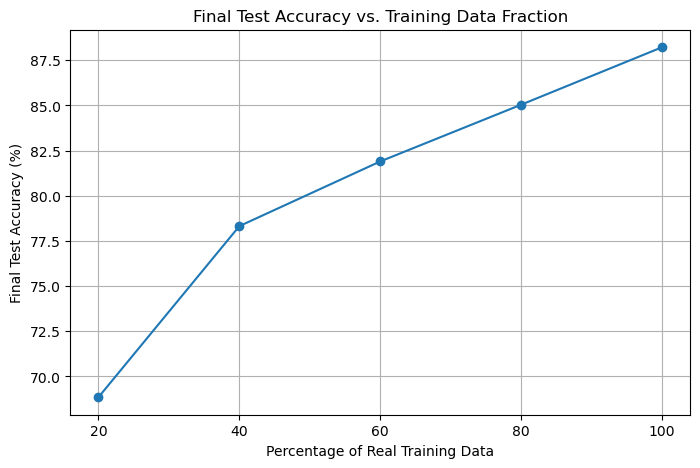

In [32]:
import re
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import ollama
from torch.optim.lr_scheduler import CosineAnnealingLR
import numpy as np

# Hyperparameters
BATCH_SIZE_TRAIN = 64
BATCH_SIZE_TEST = 1000
NUM_WORKERS = 4  # Increase if you have more CPU cores
LEARNING_RATE = 0.001
NUM_EPOCHS_LOW_DATA = 30
NUM_EPOCHS_FULL_DATA = 30
WEIGHT_DECAY = 5e-4
DROPOUT_RATE = 0.2

# Data Augmentation for Training
transform_train_strong = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.25), ratio=(0.3, 3.3)), # CutOut-like
])

# Data Augmentation for Testing (only normalization)
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

# -------------------------------------------------------------------------------
# 1) Helper: get priors from your LLM (ollama)
# -------------------------------------------------------------------------------
def get_llm_priors_for_cifar10():
    prompt = """
    I’m training a 4-layer CNN on CIFAR-10 with only 5k images (ReLU + MaxPool + 2 FC).
    For each layer’s weights and biases, propose Bayesian priors based strictly on Xavier (Glorot) initialization:
      • For weights: Normal(0, σ²) where σ = sqrt(2/(fan_in + fan_out))).
      • For biases: Delta at 0.0 (i.e., initialize to zero).
    Provide a JSON list of objects with:
      layer         (e.g. "conv1.weight", "conv1.bias"),
      prior_type    (always "Normal" for weights, "Delta" for biases),
      mean,
      std_dev       (for Normal; null for Delta),
      comment       (brief note: "Xavier init").
    Output *only* the JSON array, like:
    [
      {"layer":"conv1.weight","prior_type":"Normal","mean":0.0,"std_dev":0.1,"comment":"Xavier init"},
      {"layer":"conv1.bias","prior_type":"Delta","mean":0.0,"std_dev":null,"comment":"zeros"}
      …
    ]
    """
    try:
        resp = ollama.chat(model="llama3", messages=[{"role":"user","content":prompt}])
        txt = resp["message"]["content"].strip()
        start = txt.find('['); end = txt.rfind(']')+1
        blob = txt[start:end]
        try:
            priors = json.loads(blob)
            print("Successfully received priors from the local LLM.")
            return priors
        except json.JSONDecodeError as e:
            print(f"Error decoding JSON from LLM priors: {e}")
            print(f"Problematic blob: {blob}")
            return []
    except ollama.OllamaAPIError as e:
        print(f"Error communicating with the local LLM (Ollama): {e}")
        print("Please ensure Ollama is running and the model 'llama3' is available.")
        return []
    except ConnectionRefusedError as e:
        print(f"Connection to the local LLM (Ollama) refused: {e}")
        print("Please ensure Ollama is running and accessible.")
        return []
    except Exception as e:
        print(f"An unexpected error occurred while trying to get priors from the LLM: {e}")
        return []

def _extract_json_array(text):
    start_index = text.find('[')
    end_index = text.rfind(']')
    if start_index != -1 and end_index != -1 and start_index < end_index:
        return text[start_index : end_index + 1]
    return ""

# -------------------------------------------------------------------------------
# 2) Improved CNN Architecture with Batch Normalization and Dropout
# -------------------------------------------------------------------------------
class ImprovedCNN(nn.Module):
    def __init__(self, priors=None):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv3 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        self.conv4 = nn.Conv2d(256, 512, 3, padding=1)
        self.bn4 = nn.BatchNorm2d(512)
        self.fc1 = nn.Linear(512 * 4 * 4, 512)  # Corrected input size
        self.dropout = nn.Dropout(DROPOUT_RATE)
        self.fc2 = nn.Linear(512, 10)
        if priors:
            self._apply_priors(priors)

    def _apply_priors(self, priors):
        lookup = {}
        for name, module in self.named_modules():
            if isinstance(module, nn.Conv2d) and 'weight' in module._parameters:
                lookup[f'{name}.weight'] = module.weight
                if module.bias is not None:
                    lookup[f'{name}.bias'] = module.bias
            elif isinstance(module, nn.Linear) and 'weight' in module._parameters:
                lookup[f'{name}.weight'] = module.weight
                if module.bias is not None:
                    lookup[f'{name}.bias'] = module.bias
            elif isinstance(module, nn.BatchNorm2d) or isinstance(module, nn.MaxPool2d) or isinstance(module, nn.Dropout):
                pass

        for p in priors:
            tensor = lookup.get(p['layer'])
            if tensor is None:
                print(f"Warning: Prior specified for non-existent layer: {p['layer']}")
                continue
            typ = p.get('prior_type', 'Normal')
            if typ == 'Normal':
                m, s = p.get('mean', 0.0), p.get('std_dev', 0.0)
                if s > 0:
                    nn.init.normal_(tensor, mean=m, std=s)
                else:
                    tensor.data.fill_(m)
            elif typ == 'Mixture':
                weights, sigmas = p.get('weights', []), p.get('sigmas', [])
                combined = sum(w * s for w, s in zip(weights, sigmas))
                nn.init.normal_(tensor, mean=0.0, std=combined)
            elif typ == 'Delta':
                m = p.get('mean', 0.0)
                tensor.data.fill_(m)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

# -------------------------------------------------------------------------------
# 3) Training Function
# -------------------------------------------------------------------------------
def train(model, train_loader, optimizer, criterion, epoch, device):
    model.train()
    train_loss = 0
    correct = 0
    total = 0
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    avg_loss = train_loss / len(train_loader)
    avg_accuracy = 100. * correct / total
    print(f'Epoch: {epoch}, Loss: {avg_loss:.4f}, Accuracy: {avg_accuracy:.2f}%')
    return avg_accuracy

# -------------------------------------------------------------------------------
# 4) Evaluation Function
# -------------------------------------------------------------------------------
def evaluate(model, test_loader, criterion, device):
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_idx, (inputs, targets) in enumerate(test_loader):
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    avg_loss = test_loss / len(test_loader)
    avg_accuracy = 100. * correct / total
    print(f'Test Loss: {avg_loss:.4f}, Test Accuracy: {avg_accuracy:.2f}%')
    return avg_accuracy

# -------------------------------------------------------------------------------
# 5) Main Function
# -------------------------------------------------------------------------------
def main():
    dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    priors = get_llm_priors_for_cifar10()
    if not priors:
        print("Did not receive valid priors from the local LLM. Exiting.")
        return

    # Load CIFAR-10 datasets
    full_train_dataset = datasets.CIFAR10(root='cifar10', train=True, download=True, transform=transform_train_strong)
    full_test_dataset = datasets.CIFAR10(root='cifar10', train=False, download=True, transform=transform_test)

    fractions = [0.2, 0.4, 0.6, 0.8, 1.0]
    final_accuracies = []
    fraction_percentages = [int(f * 100) for f in fractions]

    for frac in fractions:
        print(f"\nTraining with {int(frac * 100)}% of real data")

        # Get data loaders for the current fraction
        subset_size = int(len(full_train_dataset) * frac)
        indices = np.random.choice(len(full_train_dataset), subset_size, replace=False)
        train_subset = torch.utils.data.Subset(full_train_dataset, indices)
        train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE_TRAIN,
                                         shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
        test_loader = DataLoader(full_test_dataset, batch_size=BATCH_SIZE_TEST,
                                        shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

        # Initialize model with priors
        model = ImprovedCNN(priors).to(dev)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        num_epochs = NUM_EPOCHS_LOW_DATA if frac < 1.0 else NUM_EPOCHS_FULL_DATA
        scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)

        # Train the model for all epochs
        print("Starting training...")
        for epoch in range(1, num_epochs + 1):
            train(model, train_loader, optimizer, criterion, epoch, dev)
            scheduler.step()

        # Evaluate the model only after all epochs
        print("\nEvaluating the trained model...")
        final_test_acc = evaluate(model, test_loader, criterion, dev)
        final_accuracies.append(final_test_acc)

    # Plotting final accuracies
    plt.figure(figsize=(8, 5))
    plt.plot(fraction_percentages, final_accuracies, marker='o')
    plt.xlabel('Percentage of Real Training Data')
    plt.ylabel('Final Test Accuracy (%)')
    plt.title('Final Test Accuracy vs. Training Data Fraction with LLM priors')
    plt.xticks(fraction_percentages)
    plt.grid(True)
    plt.show()

if __name__ == '__main__':
    main()